# Task 1

In [18]:
# Imports and setup 

import re
import numpy as np
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)

df = pd.read_csv("news_sample.csv")

URL_RE = re.compile(r"""(?ix)\b(https?://[^\s]+|www\.[^\s]+|[a-z0-9.-]+\.[a-z]{2,}(?:/[^\s]*)?)\b""")
EMAIL_RE = re.compile(r"""(?ix)\b[a-z0-9._%+-]+@[a-z0-9.-]+\.[a-z]{2,}\b""")
MONTH_DATE_RE = re.compile(r"""(?ix)\b(jan(?:uary)?|feb(?:ruary)?|mar(?:ch)?|apr(?:il)?|may|jun(?:e)?|jul(?:y)?|
aug(?:ust)?|sep(?:tember)?|oct(?:ober)?|nov(?:ember)?|dec(?:ember)?)\s+\d{1,2}(?:st|nd|rd|th)?(?:,)?\s+\d{4}\b""")
NUM_DATE_RE = re.compile(r"""(?x)\b(\d{1,2}[/-]\d{1,2}[/-]\d{2,4}|\d{4}[/-]\d{1,2}[/-]\d{1,2})\b""")
NUM_RE = re.compile(r"""(?x)\b\d+(?:\.\d+)?\b""")
WS_RE = re.compile(r"\s+")

In [19]:
# Clean text 

def clean_text_manual(text: str) -> str:
    if pd.isna(text): return ""
    text = str(text).lower()
    text = URL_RE.sub("<url>", text)
    text = EMAIL_RE.sub("<email>", text)
    text = MONTH_DATE_RE.sub("<date>", text)
    text = NUM_DATE_RE.sub("<date>", text)
    text = NUM_RE.sub("<num>", text)
    text = text.replace("'", "")
    return WS_RE.sub(" ", text).strip()

assert "content" in df.columns, f"'content' not found. Available columns: {list(df.columns)}"
df["content_clean"] = df["content"].apply(clean_text_manual)

# Sanity check: Create cleaned columns 
text_cols = [c for c in ["title", "content", "summary"] if c in df.columns]
assert len(text_cols) > 0, f"No text columns found. Columns: {list(df.columns)}"

for c in text_cols:
    df[f"{c}_clean"] = df[c].apply(clean_text_manual)

print("Created cleaned columns:", [f"{c}_clean" for c in text_cols])

# Sanity check: uses content_clean if it exists, otherwise first available clean col 
clean_col = "content_clean" if "content_clean" in df.columns else f"{text_cols[0]}_clean"
print("Using clean column for checks:", clean_col)

sample = df[clean_col].dropna().sample(min(50, len(df)), random_state=42).astype(str)
assert all(s == s.lower() for s in sample), f"Found non-lowercase text in {clean_col}"
assert all("  " not in s for s in sample), f"Found double spaces in {clean_col}"
print("OK: lowercase + whitespace normalization on sample.")

Created cleaned columns: ['title_clean', 'content_clean', 'summary_clean']
Using clean column for checks: content_clean
OK: lowercase + whitespace normalization on sample.


In [20]:
# Tokenize

TOKEN_RE = re.compile(r"<[^>]+>|\b\w+\b")
def tokenize(text: str): return TOKEN_RE.findall(text)

clean_tokens = []
for t in df["content_clean"].fillna("").astype(str):
    clean_tokens.extend(tokenize(t))

# Sanity check: tokenization preserves placeholders
test_str = "visit <url> email <email> on <date> pay <num>"
toks = tokenize(test_str)
assert "<url>" in toks and "<email>" in toks and "<date>" in toks and "<num>" in toks, (
    f"Tokenizer did not preserve placeholders correctly. Tokens: {toks}"
)
print("OK: tokenizer preserves <...> placeholders.")

# No empty tokens
assert all(t.strip() != "" for t in toks), "Found empty/blank tokens"
print("OK: no empty tokens.")

OK: tokenizer preserves <...> placeholders.
OK: no empty tokens.


In [21]:
# Stopwords
eng_stop = set(stopwords.words("english"))
clean_tokens_no_stop = [t for t in clean_tokens if t not in eng_stop]


# Sanity check: stopword removal
v_before = len(set(clean_tokens))
v_after = len(set(clean_tokens_no_stop))
print("Vocab before stopword removal:", v_before)
print("Vocab after stopword removal:", v_after)

assert v_after <= v_before, "Stopword removal increased vocabulary (should not happen)"
assert len(clean_tokens_no_stop) <= len(clean_tokens), "Stopword removal increased token count"
print("OK: stopword removal reduces (or keeps) vocab and token count.")

# Spot-check that common stopwords are gone (probabilistic; may fail on tiny datasets)
common_stops = {"the", "and", "of", "to"}
present = common_stops.intersection(set(clean_tokens_no_stop))
print("Common stopwords still present (may be OK depending on tokenizer/data):", present)

Vocab before stopword removal: 15431
Vocab after stopword removal: 15284
OK: stopword removal reduces (or keeps) vocab and token count.
Common stopwords still present (may be OK depending on tokenizer/data): set()


In [22]:
# Stemming
stemmer = PorterStemmer()
clean_tokens_stem = [
    t if (t.startswith("<") and t.endswith(">")) else stemmer.stem(t)
    for t in clean_tokens_no_stop
]

# Sanity checks: stemming
v_before = len(set(clean_tokens_no_stop))
v_after = len(set(clean_tokens_stem))
print("Vocab before stemming:", v_before)
print("Vocab after stemming:", v_after)

assert v_after <= v_before, "Stemming increased vocabulary (unexpected)"
print("OK: stemming does not increase vocabulary.")

# Ensure placeholders unchanged
placeholders_before = {t for t in clean_tokens_no_stop if t.startswith("<") and t.endswith(">")}
placeholders_after  = {t for t in clean_tokens_stem if t.startswith("<") and t.endswith(">")}
assert placeholders_before == placeholders_after, "Placeholders changed during stemming"
print("OK: placeholders preserved during stemming.")

Vocab before stemming: 15284
Vocab after stemming: 10009
OK: stemming does not increase vocabulary.
OK: placeholders preserved during stemming.


In [23]:
def vocab_size(tokens):
    return len(set(tokens))

V_clean = vocab_size(clean_tokens)
V_no_stop = vocab_size(clean_tokens_no_stop)
V_stem = vocab_size(clean_tokens_stem)

# Reduction rates
stop_reduction = 1 - (V_no_stop / V_clean) if V_clean > 0 else 0.0
stem_reduction = 1 - (V_stem / V_no_stop) if V_no_stop > 0 else 0.0

print("TASK 1 RESULTS")
print(f"Vocabulary size after cleaning:           {V_clean}")
print(f"Vocabulary size after stopword removal:  {V_no_stop}")
print(f"Stopword reduction rate:                 {stop_reduction:.4f} ({stop_reduction*100:.2f}%)")
print(f"Vocabulary size after stemming:          {V_stem}")
print(f"Stemming reduction rate:                 {stem_reduction:.4f} ({stem_reduction*100:.2f}%)")

# sanity checks
assert V_no_stop <= V_clean, "Stopword removal should not increase vocabulary size"
assert V_stem <= V_no_stop, "Stemming should not increase vocabulary size"
print("OK: vocab decreases monotonically (as expected).")

TASK 1 RESULTS
Vocabulary size after cleaning:           15431
Vocabulary size after stopword removal:  15284
Stopword reduction rate:                 0.0095 (0.95%)
Vocabulary size after stemming:          10009
Stemming reduction rate:                 0.3451 (34.51%)
OK: vocab decreases monotonically (as expected).


In [24]:
# Save cleaned dataset to CSV

import os

os.makedirs("processed_data", exist_ok=True)
output_path = os.path.join("processed_data", "news_sample_cleaned.csv")

df.to_csv(output_path, index=False)

print(f"Saved cleaned dataset to {output_path}")

Saved cleaned dataset to processed_data\news_sample_cleaned.csv


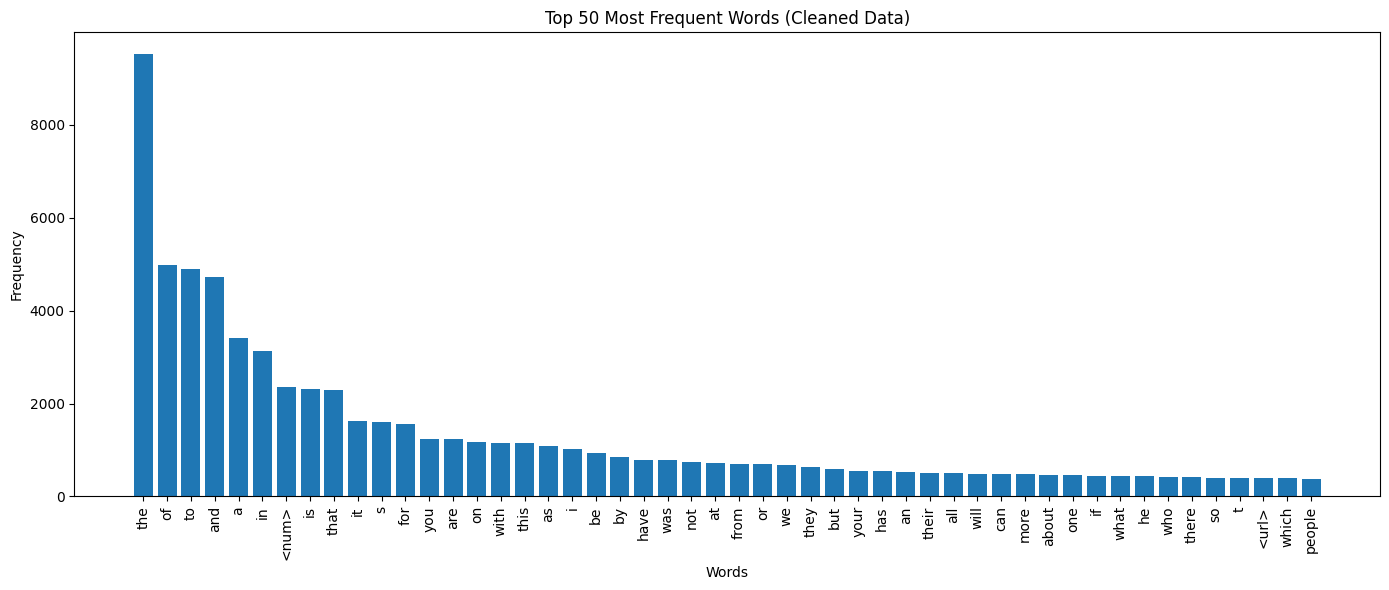

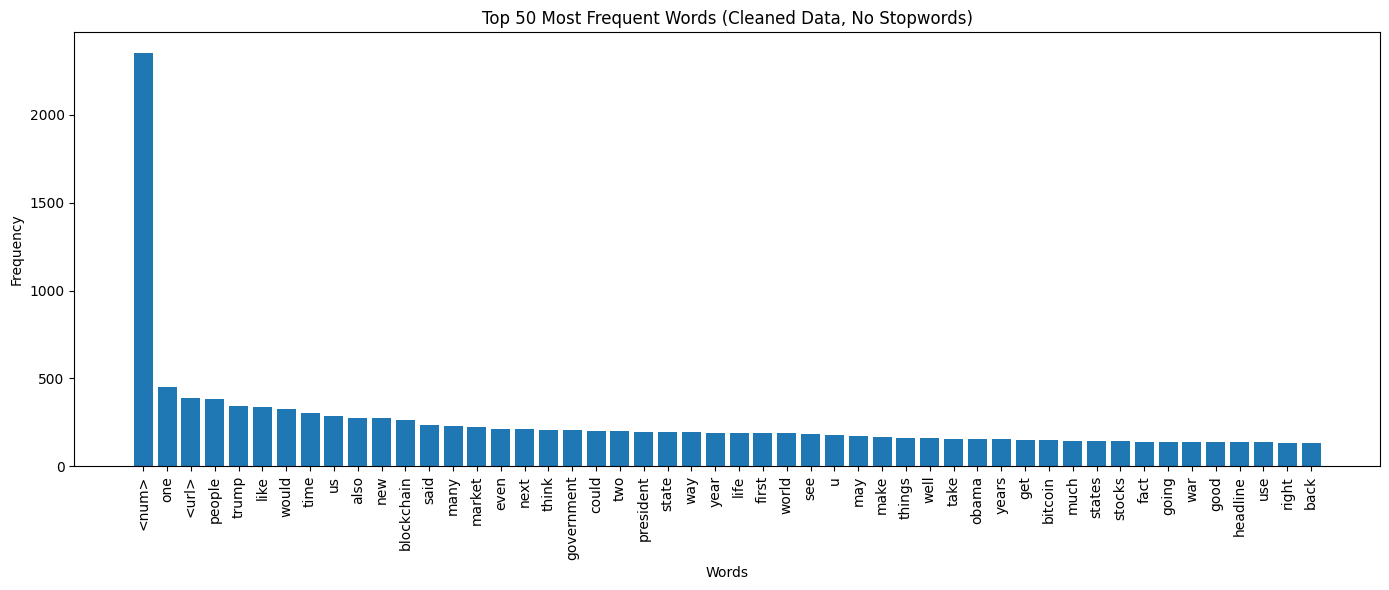

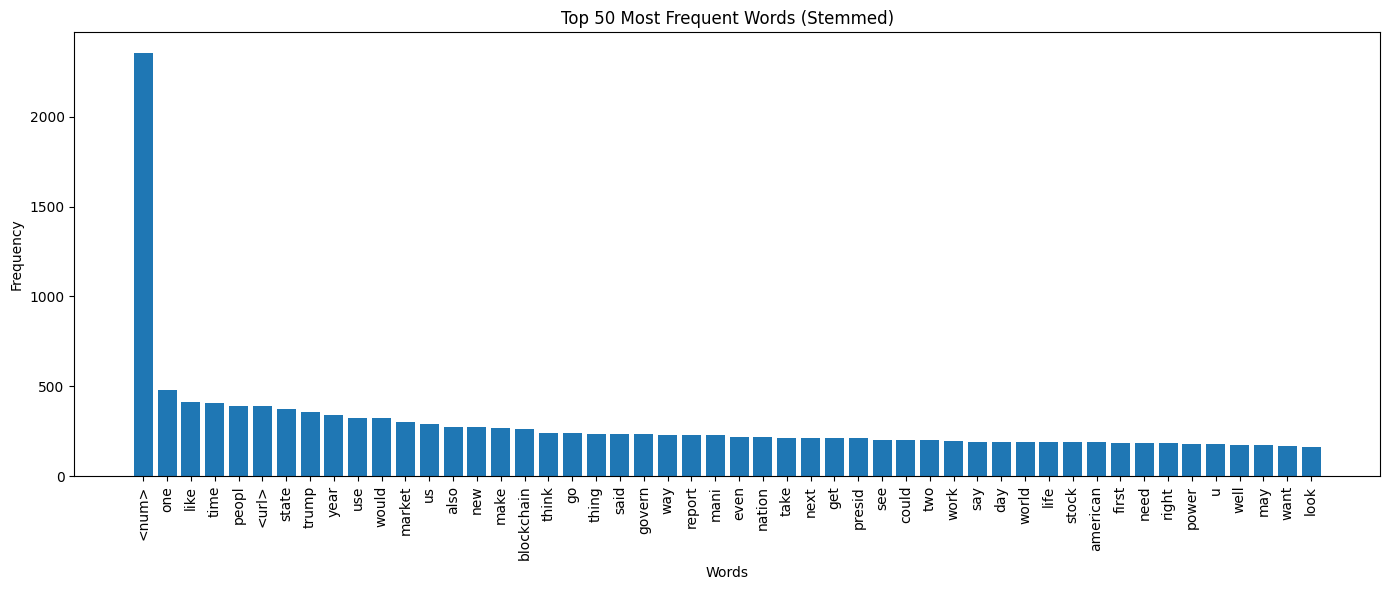

In [25]:
# Plots

from collections import Counter
import matplotlib.pyplot as plt

def plot_top_tokens_bar(tokens=None, freq=None, top_n=50, title="Top tokens", figsize=(14, 6), rotation=90):

    if freq is None:
        if tokens is None:
            raise ValueError("Du skal give enten 'tokens' eller 'freq'.")
        freq = Counter(tokens)
    else:
        # Secure counter-like interface
        if not hasattr(freq, "most_common"):
            freq = Counter(freq)

    top = freq.most_common(top_n)
    words = [w for w, _ in top]
    counts = [c for _, c in top]

    plt.figure(figsize=figsize)
    plt.bar(words, counts)
    plt.xticks(rotation=rotation)
    plt.title(title)
    plt.xlabel("Words")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

plot_top_tokens_bar(
    tokens=clean_tokens,
    top_n=50,
    title="Top 50 Most Frequent Words (Cleaned Data)"
)

# Without stopwords 

from nltk.corpus import stopwords
eng_stop = set(stopwords.words("english"))

clean_tokens_no_stop = [t for t in clean_tokens if t not in eng_stop]

plot_top_tokens_bar(
    tokens=clean_tokens_no_stop,
    top_n=50,
    title="Top 50 Most Frequent Words (Cleaned Data, No Stopwords)"
)

# After stemming:

plot_top_tokens_bar(
    tokens=clean_tokens_stem,
    top_n=50,
    title="Top 50 Most Frequent Words (Stemmed)"
)


In [26]:
# Split 80/10/10
n = len(df)
rng = np.random.default_rng(42)
perm = rng.permutation(n)
train, val, test = perm[:int(0.8*n)], perm[int(0.8*n):int(0.9*n)], perm[int(0.9*n):]
df_train, df_val, df_test = df.iloc[train], df.iloc[val], df.iloc[test]


# Sanity checks: splitting
n = len(df)
assert len(df_train) + len(df_val) + len(df_test) == n, "Split sizes do not sum to N"

# Check approximate proportions (allow rounding tolerance)
p_train, p_val, p_test = len(df_train)/n, len(df_val)/n, len(df_test)/n
print("Split proportions:", p_train, p_val, p_test)
assert abs(p_train - 0.8) < 0.02, "Train proportion far from 0.8"
assert abs(p_val - 0.1) < 0.02, "Val proportion far from 0.1"
assert abs(p_test - 0.1) < 0.02, "Test proportion far from 0.1"

# Check no overlap via original indices
train_ids = set(df_train.index)
val_ids   = set(df_val.index)
test_ids  = set(df_test.index)



Split proportions: 0.8 0.1 0.1


## Make the pipeline reusable

In [27]:
from collections import Counter
import matplotlib.pyplot as plt
import os

def clean_text_manual(text: str) -> str:
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = URL_RE.sub("<url>", text)
    text = EMAIL_RE.sub("<email>", text)
    text = MONTH_DATE_RE.sub("<date>", text)
    text = NUM_DATE_RE.sub("<date>", text)
    text = NUM_RE.sub("<num>", text)
    text = text.replace("'", "")
    return WS_RE.sub(" ", text).strip()

TOKEN_RE = re.compile(r"<[^>]+>|\b\w+\b")

def tokenize(text: str):
    return TOKEN_RE.findall(str(text))

eng_stop = set(stopwords.words("english"))
stemmer = PorterStemmer()

def remove_stopwords(tokens):
    return [t for t in tokens if t not in eng_stop]

def stem_tokens(tokens):
    return [
        t if (t.startswith("<") and t.endswith(">")) else stemmer.stem(t)
        for t in tokens
    ]

def vocab_size(tokens):
    return len(set(tokens))

def reduction_rate(before, after):
    return 1 - (after / before) if before > 0 else 0.0

def flatten_token_lists(token_series):
    all_tokens = []
    for toks in token_series:
        all_tokens.extend(toks)
    return all_tokens

## Preprocessing function for both sample and 995K

In [28]:
def preprocess_dataframe(df, text_col="content"):
    df = df.copy()

    assert text_col in df.columns, f"Column '{text_col}' not found. Available columns: {list(df.columns)}"

    # Clean text
    df[f"{text_col}_clean"] = df[text_col].apply(clean_text_manual)

    # Tokenize
    df[f"{text_col}_tokens"] = df[f"{text_col}_clean"].apply(tokenize)

    # Remove stopwords
    df[f"{text_col}_tokens_nostop"] = df[f"{text_col}_tokens"].apply(remove_stopwords)

    # Stem
    df[f"{text_col}_tokens_stem"] = df[f"{text_col}_tokens_nostop"].apply(stem_tokens)

    # Simple per-document features for exploration
    df["n_chars"] = df[f"{text_col}_clean"].str.len()
    df["n_tokens"] = df[f"{text_col}_tokens"].apply(len)
    df["n_urls"] = df[f"{text_col}_clean"].str.count(re.escape("<url>"))
    df["n_dates"] = df[f"{text_col}_clean"].str.count(re.escape("<date>"))
    df["n_nums"] = df[f"{text_col}_clean"].str.count(re.escape("<num>"))

    # Missing-value indicator
    df["content_missing"] = df[text_col].isna()

    return df


## Run it on the sample file again in a more unified way

In [29]:
sample_df = pd.read_csv("news_sample.csv")
sample_df = preprocess_dataframe(sample_df, text_col="content")

sample_tokens_clean = flatten_token_lists(sample_df["content_tokens"])
sample_tokens_nostop = flatten_token_lists(sample_df["content_tokens_nostop"])
sample_tokens_stem = flatten_token_lists(sample_df["content_tokens_stem"])

V_clean = vocab_size(sample_tokens_clean)
V_nostop = vocab_size(sample_tokens_nostop)
V_stem = vocab_size(sample_tokens_stem)

print("TASK 1 RESULTS (news_sample.csv)")
print(f"Vocabulary after cleaning:          {V_clean}")
print(f"Vocabulary after stopword removal:  {V_nostop}")
print(f"Reduction after stopword removal:   {reduction_rate(V_clean, V_nostop):.4f} ({reduction_rate(V_clean, V_nostop)*100:.2f}%)")
print(f"Vocabulary after stemming:          {V_stem}")
print(f"Reduction after stemming:           {reduction_rate(V_nostop, V_stem):.4f} ({reduction_rate(V_nostop, V_stem)*100:.2f}%)")

TASK 1 RESULTS (news_sample.csv)
Vocabulary after cleaning:          15431
Vocabulary after stopword removal:  15284
Reduction after stopword removal:   0.0095 (0.95%)
Vocabulary after stemming:          10009
Reduction after stemming:           0.3451 (34.51%)


## Text preprocessing

In this task, we preprocess the text data from the FakeNewsCorpus sample dataset in order to make it suitable for further analysis and modeling.

We represent the dataset as a Pandas DataFrame, since this structure allows us to efficiently combine raw text, cleaned text, tokenized representations, and engineered features within a single table. It also enables easy manipulation, filtering, and export of the data.

The preprocessing pipeline consists of the following steps:

1. **Text cleaning**:  
   All text is converted to lowercase and normalized. URLs, email addresses, dates, and numbers are replaced with placeholder tokens such as `<url>`, `<email>`, `<date>`, and `<num>`. This ensures consistency and reduces noise caused by irrelevant variations.

2. **Tokenization**:  
   The cleaned text is split into tokens using a regular expression that preserves placeholder tokens. This step transforms each document into a sequence of words or symbols that can be analyzed computationally.

3. **Stopword removal**:  
   Common English stopwords (e.g., "the", "and", "of") are removed using the NLTK stopword list. This reduces the influence of high-frequency function words that carry limited semantic meaning.

4. **Stemming**:  
   Porter stemming is applied to reduce words to their base or root forms (e.g., "running" â†’ "run", "years" â†’ "year"). This reduces vocabulary size and helps group similar word forms together.

These preprocessing steps reduce noise, normalize the data, and make the text representation more compact and informative for downstream tasks such as classification.

# Task 2
We now apply exactly the same preprocessing pipeline to the larger 995K subset. This ensures consistency between the small sample used for development and the larger dataset used for further analysis and modeling.

In [ ]:
import pandas as pd
import os

input_path = "995,000_rows.csv"
output_path = "processed_data/fakenews_995k_processed.csv"

os.makedirs("processed_data", exist_ok=True)

chunk_size = 20000
first_chunk = True

for i, chunk in enumerate(pd.read_csv(input_path, chunksize=chunk_size)):
    print(f"Processing chunk {i+1}...")
    chunk_processed = preprocess_dataframe(chunk, text_col="content")

    if first_chunk:
        chunk_processed.to_csv(output_path, index=False, mode="w")
        first_chunk = False
    else:
        chunk_processed.to_csv(output_path, index=False, mode="a", header=False)

print("Done processing large dataset!")

Processing chunk 1...
Processing chunk 2...
Processing chunk 3...
Processing chunk 4...
Processing chunk 5...
Processing chunk 6...
Processing chunk 7...
Processing chunk 8...
Processing chunk 9...
Processing chunk 10...
Processing chunk 11...
Processing chunk 12...
Processing chunk 13...
Processing chunk 14...
Processing chunk 15...
Processing chunk 16...
Processing chunk 17...
Processing chunk 18...
Processing chunk 19...
Processing chunk 20...
Processing chunk 21...
Processing chunk 22...
Processing chunk 23...
Processing chunk 24...
Processing chunk 25...
Processing chunk 26...
Processing chunk 27...
Processing chunk 28...
Processing chunk 29...
Processing chunk 30...
Processing chunk 31...
Processing chunk 32...
Processing chunk 33...
Processing chunk 34...
Processing chunk 35...
Processing chunk 36...
Processing chunk 37...
Processing chunk 38...
Processing chunk 39...
Processing chunk 40...
Processing chunk 41...
Processing chunk 42...
Processing chunk 43...
Processing chunk 44.

## Task 3

## Basis-statistik

In [35]:
import pandas as pd

input_path = "processed_data/fakenews_995k_processed.csv"
chunk_size = 20000

total_rows = 0
total_urls = 0
total_dates = 0
total_nums = 0

token_lengths = []

for chunk in pd.read_csv(input_path, chunksize=chunk_size):
    total_rows += len(chunk)
    
    total_urls += chunk["n_urls"].sum()
    total_dates += chunk["n_dates"].sum()
    total_nums += chunk["n_nums"].sum()
    
    token_lengths.extend(chunk["n_tokens"].tolist())

print("BASIC DATASET STATISTICS")
print("Rows:", total_rows)
print("Average tokens per article:", sum(token_lengths) / len(token_lengths))
print("Average URLs per article:", total_urls / total_rows)
print("Average dates per article:", total_dates / total_rows)
print("Average numbers per article:", total_nums / total_rows)

BASIC DATASET STATISTICS
Rows: 995000
Average tokens per article: 475.65270753768846
Average URLs per article: 0.7182964824120603
Average dates per article: 0.388113567839196
Average numbers per article: 8.296309547738694


## Distribution as a histogram

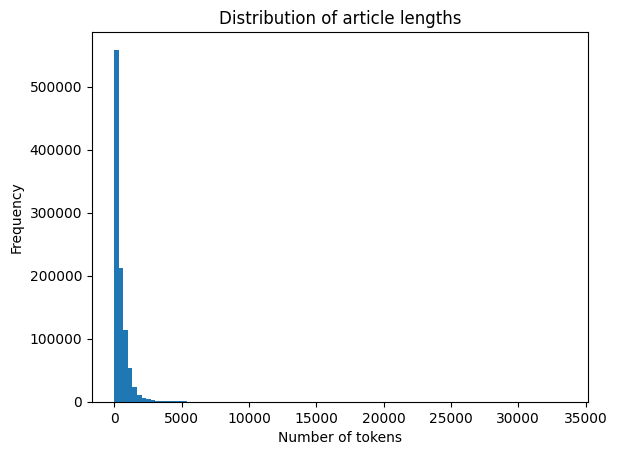

In [36]:
import matplotlib.pyplot as plt

plt.hist(token_lengths, bins=100)
plt.title("Distribution of article lengths")
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.show()

## Top words before/after stopwords/stemming

In [37]:
from collections import Counter
import pandas as pd

input_path = "processed_data/fakenews_995k_processed.csv"
chunk_size = 20000

freq_clean = Counter()
freq_nostop = Counter()
freq_stem = Counter()

for chunk in pd.read_csv(input_path, chunksize=chunk_size):
    
    for toks in chunk["content_tokens"]:
        if isinstance(toks, str):
            toks = eval(toks)  # Because lists are stored as strings in CSV
        freq_clean.update(toks)
        
    for toks in chunk["content_tokens_nostop"]:
        if isinstance(toks, str):
            toks = eval(toks)
        freq_nostop.update(toks)
        
    for toks in chunk["content_tokens_stem"]:
        if isinstance(toks, str):
            toks = eval(toks)
        freq_stem.update(toks)

print("Top 20 words (cleaned):")
print(freq_clean.most_common(20))

print("\nTop 20 words (no stopwords):")
print(freq_nostop.most_common(20))

print("\nTop 20 words (stemmed):")
print(freq_stem.most_common(20))

Top 20 words (cleaned):
[('the', 26199213), ('to', 12654702), ('of', 12487482), ('and', 11504408), ('a', 9988233), ('in', 8712168), ('<num>', 8252592), ('that', 5600546), ('is', 5070993), ('for', 4382901), ('on', 3513776), ('it', 3360117), ('s', 3254643), ('with', 2831681), ('as', 2801780), ('was', 2446252), ('are', 2442459), ('by', 2342525), ('i', 2314411), ('this', 2282242)]

Top 20 words (no stopwords):
[('<num>', 8252592), ('said', 1413131), ('one', 1113474), ('new', 1063161), ('would', 964217), ('people', 896948), ('like', 722428), ('<url>', 711460), ('also', 691876), ('us', 670107), ('time', 644164), ('year', 574406), ('mr', 564888), ('even', 538415), ('two', 536814), ('first', 519224), ('state', 516830), ('president', 505656), ('news', 494181), ('years', 490372)]

Top 20 words (stemmed):
[('<num>', 8252592), ('said', 1413168), ('one', 1165241), ('year', 1064782), ('new', 1063338), ('state', 977004), ('would', 964221), ('time', 945727), ('peopl', 922950), ('like', 876782), ('<url

## Chunked analysis

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import ast
import numpy as np

input_path = "processed_data/fakenews_995k_processed.csv"
chunk_size = 20000

freq_clean = Counter()
freq_nostop = Counter()
freq_stem = Counter()

token_lengths = []
url_counts = []
date_counts = []
num_counts = []

total_rows = 0
missing_content_count = 0
url_heavy_count = 0
date_heavy_count = 0
num_heavy_count = 0
short_count = 0
long_count = 0

for i, chunk in enumerate(pd.read_csv(input_path, chunksize=chunk_size)):
    print(f"Analyzing chunk {i+1}...")

    total_rows += len(chunk)

    # Numeric columns for histograms / stats
    token_lengths.extend(chunk["n_tokens"].tolist())
    url_counts.extend(chunk["n_urls"].tolist())
    date_counts.extend(chunk["n_dates"].tolist())
    num_counts.extend(chunk["n_nums"].tolist())

    # Candidate observation counts
    if "content_missing" in chunk.columns:
        missing_content_count += chunk["content_missing"].sum()

    url_heavy_count += (chunk["n_urls"] >= 3).sum()
    date_heavy_count += (chunk["n_dates"] >= 2).sum()
    num_heavy_count += (chunk["n_nums"] >= 5).sum()
    short_count += (chunk["n_tokens"] < 50).sum()
    long_count += (chunk["n_tokens"] > 1000).sum()

    # Token counters
    for toks in chunk["content_tokens"]:
        if isinstance(toks, str):
            toks = ast.literal_eval(toks)
        freq_clean.update(toks)

    for toks in chunk["content_tokens_nostop"]:
        if isinstance(toks, str):
            toks = ast.literal_eval(toks)
        freq_nostop.update(toks)

    for toks in chunk["content_tokens_stem"]:
        if isinstance(toks, str):
            toks = ast.literal_eval(toks)
        freq_stem.update(toks)

print("Finished chunked analysis.")

Analyzing chunk 1...
Analyzing chunk 2...
Analyzing chunk 3...
Analyzing chunk 4...
Analyzing chunk 5...
Analyzing chunk 6...
Analyzing chunk 7...
Analyzing chunk 8...
Analyzing chunk 9...
Analyzing chunk 10...
Analyzing chunk 11...
Analyzing chunk 12...
Analyzing chunk 13...
Analyzing chunk 14...
Analyzing chunk 15...
Analyzing chunk 16...
Analyzing chunk 17...
Analyzing chunk 18...
Analyzing chunk 19...
Analyzing chunk 20...
Analyzing chunk 21...
Analyzing chunk 22...
Analyzing chunk 23...
Analyzing chunk 24...
Analyzing chunk 25...
Analyzing chunk 26...
Analyzing chunk 27...
Analyzing chunk 28...
Analyzing chunk 29...
Analyzing chunk 30...
Analyzing chunk 31...
Analyzing chunk 32...
Analyzing chunk 33...
Analyzing chunk 34...
Analyzing chunk 35...
Analyzing chunk 36...
Analyzing chunk 37...
Analyzing chunk 38...
Analyzing chunk 39...
Analyzing chunk 40...
Analyzing chunk 41...
Analyzing chunk 42...
Analyzing chunk 43...
Analyzing chunk 44...
Analyzing chunk 45...
Analyzing chunk 46.

## Chunked barplots

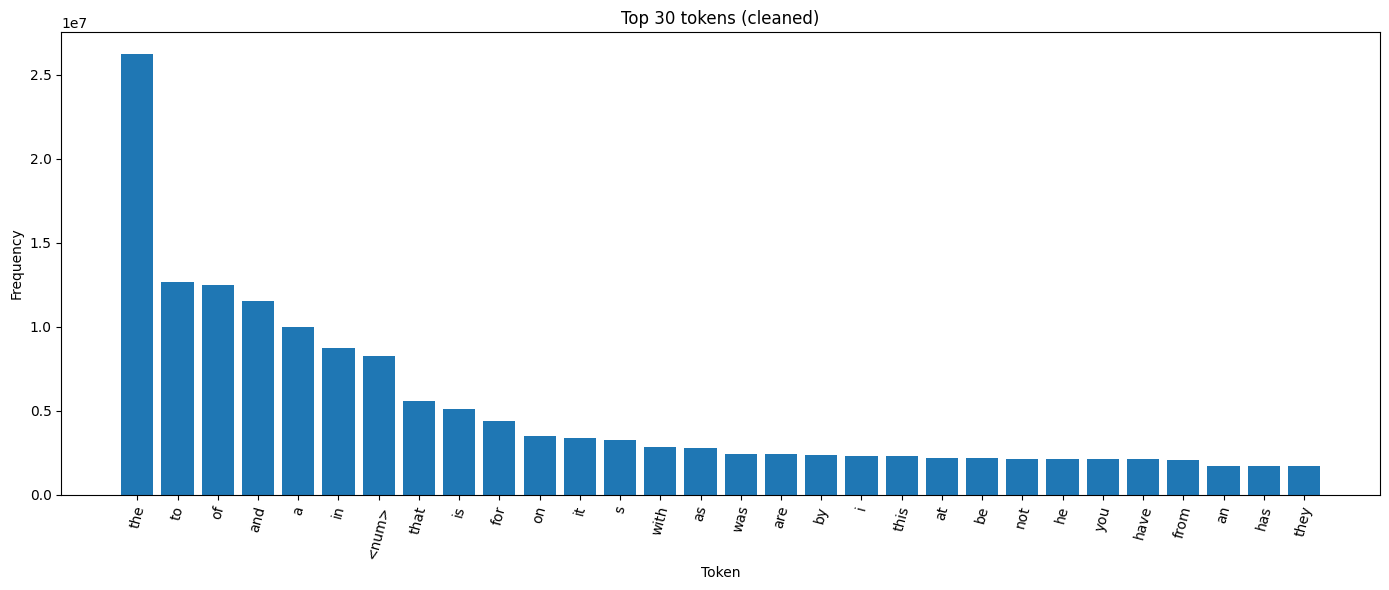

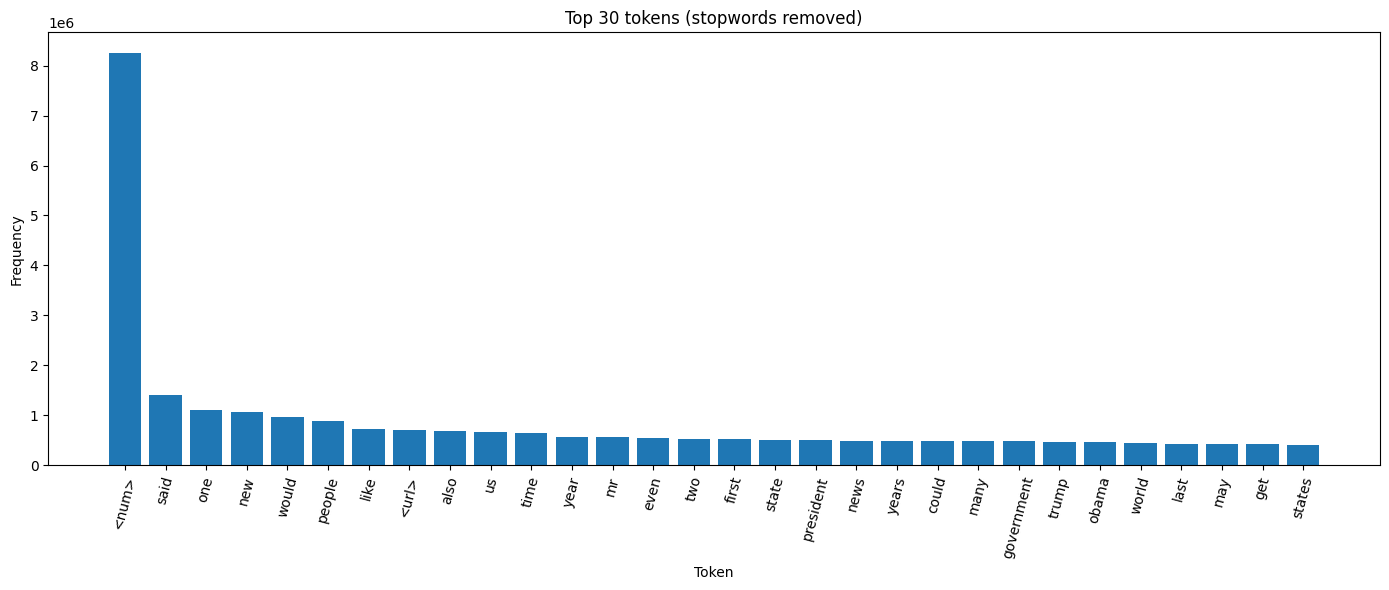

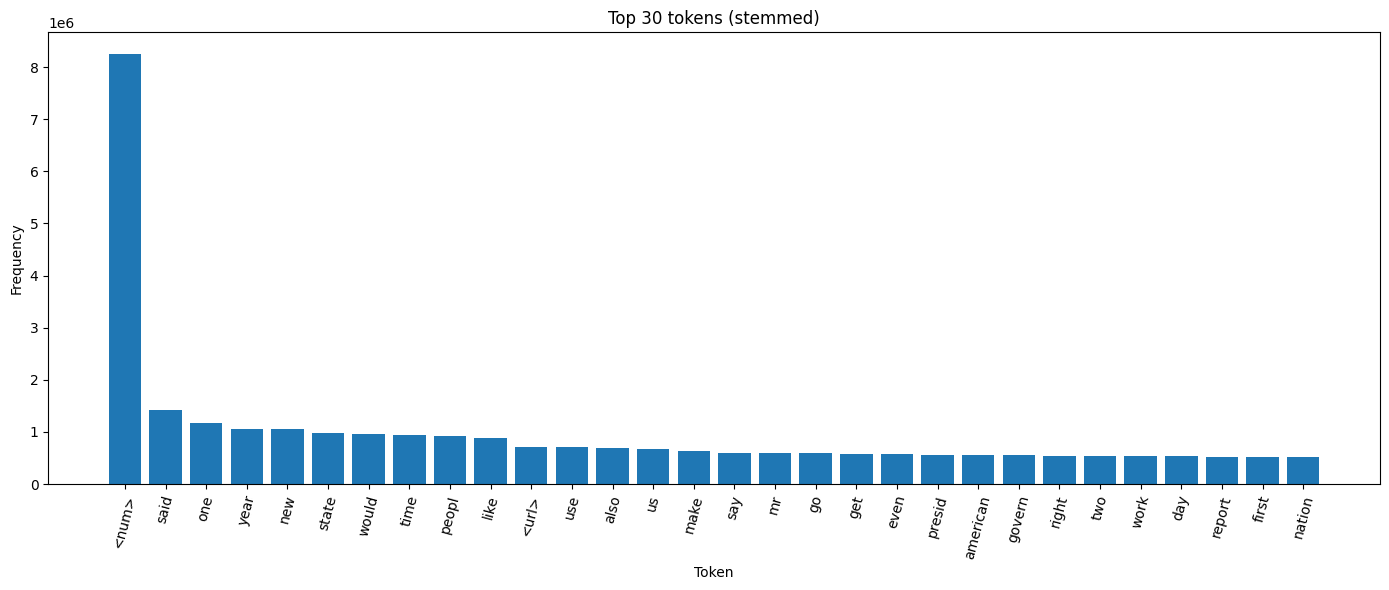

In [39]:
def plot_top_tokens(freq, top_n=30, title="Top tokens", rotation=75):
    top = freq.most_common(top_n)
    words = [w for w, _ in top]
    counts = [c for _, c in top]

    plt.figure(figsize=(14, 6))
    plt.bar(words, counts)
    plt.xticks(rotation=rotation)
    plt.title(title)
    plt.xlabel("Token")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

plot_top_tokens(freq_clean, top_n=30, title="Top 30 tokens (cleaned)")
plot_top_tokens(freq_nostop, top_n=30, title="Top 30 tokens (stopwords removed)")
plot_top_tokens(freq_stem, top_n=30, title="Top 30 tokens (stemmed)")

## Frequency curve

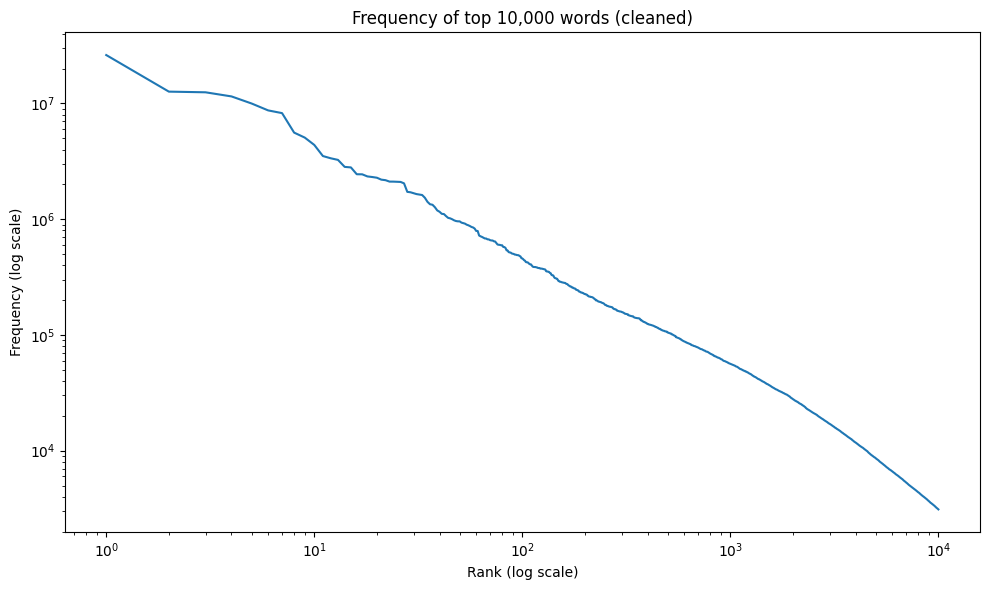

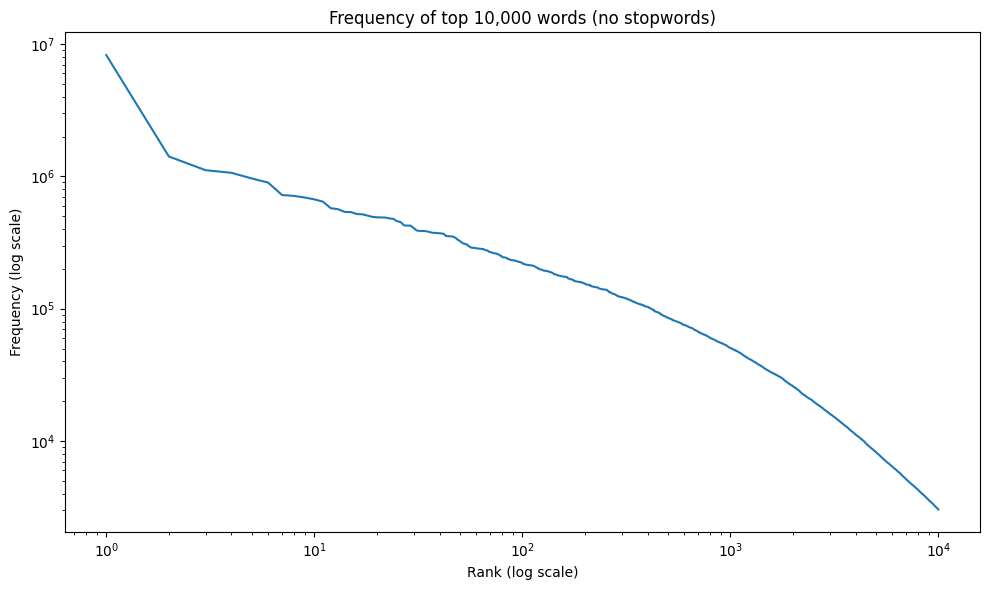

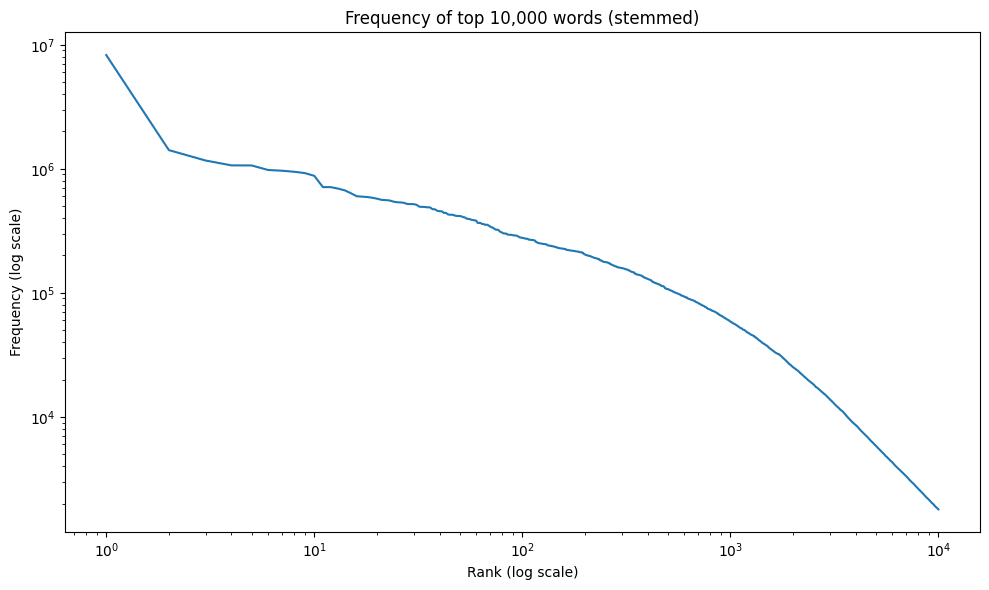

In [40]:
def plot_frequency_curve(freq, top_n=10000, title="Word frequency curve"):
    counts = [count for _, count in freq.most_common(top_n)]

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(counts) + 1), counts)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Rank (log scale)")
    plt.ylabel("Frequency (log scale)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_frequency_curve(freq_clean, top_n=10000, title="Frequency of top 10,000 words (cleaned)")
plot_frequency_curve(freq_nostop, top_n=10000, title="Frequency of top 10,000 words (no stopwords)")
plot_frequency_curve(freq_stem, top_n=10000, title="Frequency of top 10,000 words (stemmed)")

## Distributionsplots

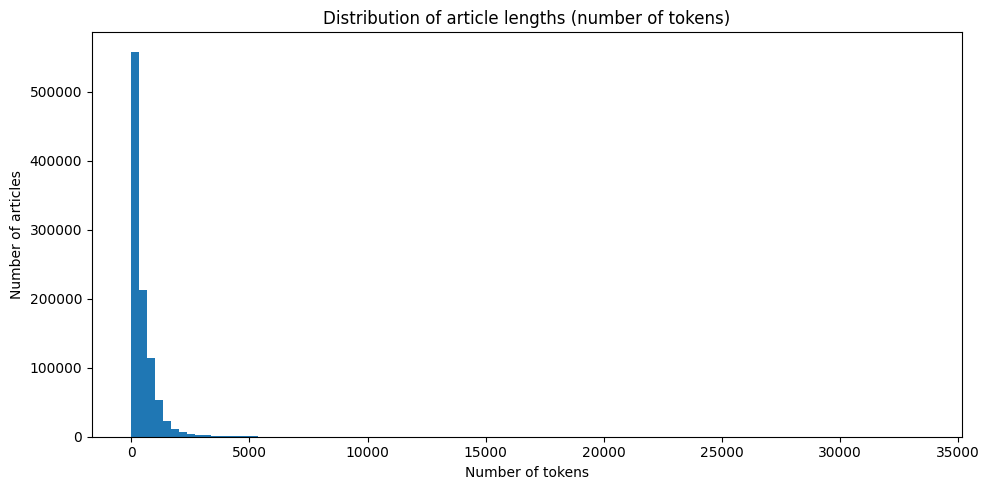

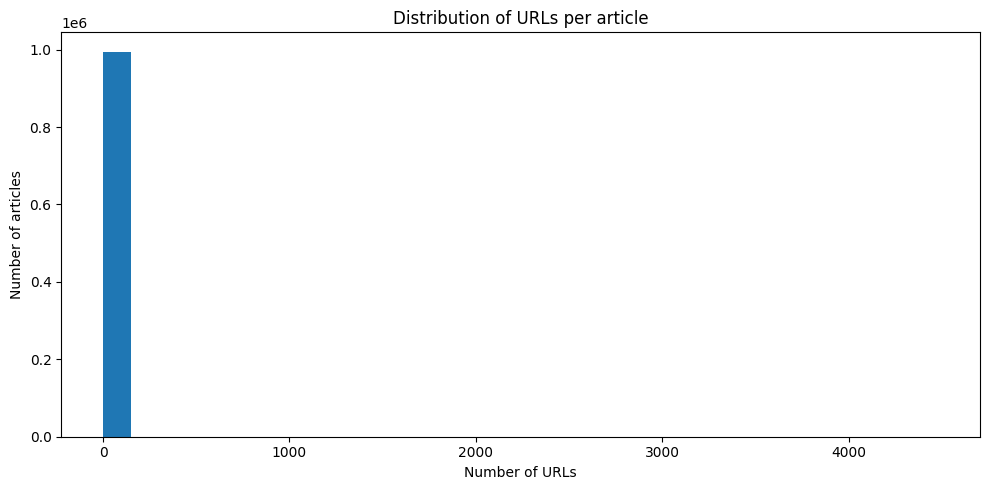

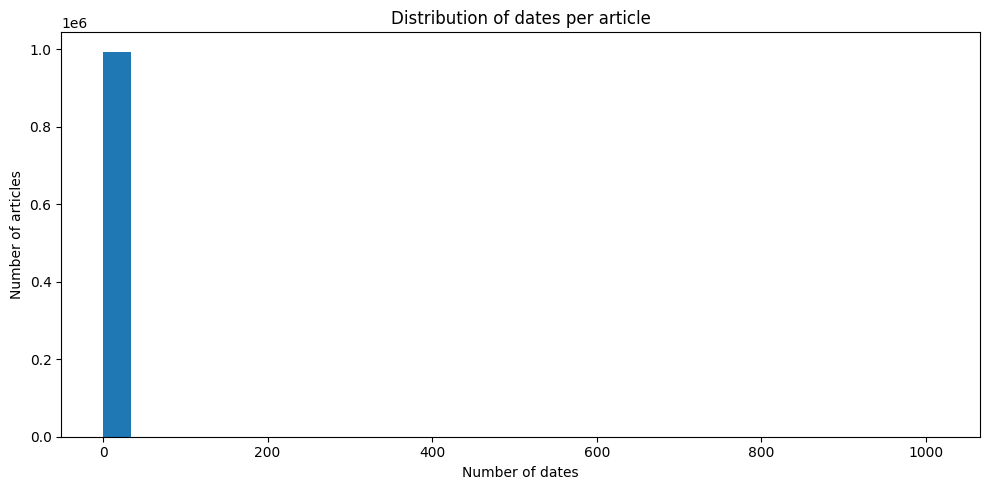

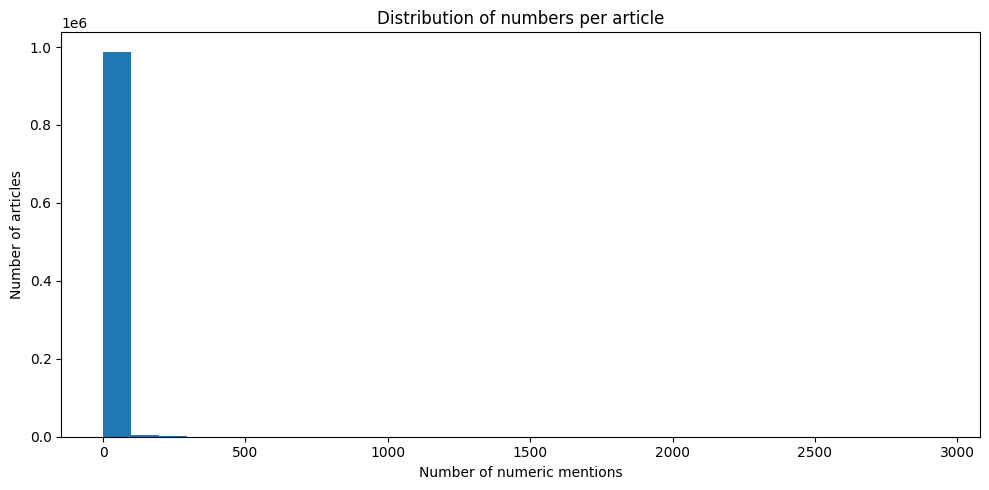

In [41]:
plt.figure(figsize=(10, 5))
plt.hist(token_lengths, bins=100)
plt.title("Distribution of article lengths (number of tokens)")
plt.xlabel("Number of tokens")
plt.ylabel("Number of articles")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(url_counts, bins=30)
plt.title("Distribution of URLs per article")
plt.xlabel("Number of URLs")
plt.ylabel("Number of articles")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(date_counts, bins=30)
plt.title("Distribution of dates per article")
plt.xlabel("Number of dates")
plt.ylabel("Number of articles")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(num_counts, bins=30)
plt.title("Distribution of numbers per article")
plt.xlabel("Number of numeric mentions")
plt.ylabel("Number of articles")
plt.tight_layout()
plt.show()

## Candidate observations

In [42]:
print("CANDIDATE OBSERVATIONS")

missing_content_pct = 100 * missing_content_count / total_rows
url_heavy_pct = 100 * url_heavy_count / total_rows
date_heavy_pct = 100 * date_heavy_count / total_rows
num_heavy_pct = 100 * num_heavy_count / total_rows
short_pct = 100 * short_count / total_rows
long_pct = 100 * long_count / total_rows

print(f"1. Percentage of rows with missing content: {missing_content_pct:.2f}%")
print(f"2. Percentage of articles with at least 3 URLs: {url_heavy_pct:.2f}%")
print(f"3. Percentage of articles with at least 2 date mentions: {date_heavy_pct:.2f}%")
print(f"4. Percentage of articles with at least 5 numeric mentions: {num_heavy_pct:.2f}%")
print(f"5. Percentage of very short articles (<50 tokens): {short_pct:.2f}%")
print(f"6. Percentage of very long articles (>1000 tokens): {long_pct:.2f}%")

CANDIDATE OBSERVATIONS
1. Percentage of rows with missing content: 0.00%
2. Percentage of articles with at least 3 URLs: 7.15%
3. Percentage of articles with at least 2 date mentions: 5.33%
4. Percentage of articles with at least 5 numeric mentions: 39.25%
5. Percentage of very short articles (<50 tokens): 13.84%
6. Percentage of very long articles (>1000 tokens): 11.25%


## Basic statistics

In [43]:
print("BASIC DATASET STATISTICS")
print("Rows:", total_rows)
print("Average tokens per article:", np.mean(token_lengths))
print("Median tokens per article:", np.median(token_lengths))
print("Average URLs per article:", np.mean(url_counts))
print("Average dates per article:", np.mean(date_counts))
print("Average numbers per article:", np.mean(num_counts))
print("Max tokens in one article:", np.max(token_lengths))
print("Min tokens in one article:", np.min(token_lengths))

BASIC DATASET STATISTICS
Rows: 995000
Average tokens per article: 475.65270753768846
Median tokens per article: 303.0
Average URLs per article: 0.7182964824120603
Average dates per article: 0.388113567839196
Average numbers per article: 8.296309547738694
Max tokens in one article: 33495
Min tokens in one article: 0


## Data Exploration and Observations

We performed exploratory analysis on the processed 995K FakeNewsCorpus subset to better understand the statistical properties of the dataset and to identify meaningful patterns in the text.

### Observation 1: Highly skewed article-length distribution

The distribution of article lengths (measured in number of tokens) is strongly right-skewed. The mean article length is approximately 475.7 tokens, while the median is only 303 tokens, indicating that a relatively small number of very long articles significantly increase the average. This is further supported by the presence of extreme outliers, with some articles exceeding 33,000 tokens.

At the same time, 13.84% of articles contain fewer than 50 tokens, while 11.25% contain more than 1000 tokens. This demonstrates substantial heterogeneity in document size and suggests that the dataset includes both very short and very long texts, which may correspond to different types or qualities of articles.

### Observation 2: High prevalence of numeric information

Numeric values appear to be a prominent feature of the dataset. On average, each article contains approximately 8.30 numeric mentions, compared to 0.72 URLs and 0.39 date mentions. Furthermore, 39.25% of articles contain at least five numeric values, whereas only 7.15% contain at least three URLs and 5.33% contain at least two date mentions.

This indicates that quantitative information (e.g., statistics, measurements, dates, or financial figures) is widely used across the corpus. The prominence of numeric tokens suggests that they may carry important semantic or stylistic information relevant for downstream tasks such as fake news detection.

### Observation 3: Impact of stopword removal and stemming on token distributions

The preprocessing steps significantly alter the distribution of tokens. Before stopword removal, the most frequent tokens are dominated by common function words such as "the", "to", "of", and "and". After removing stopwords, more content-bearing words such as "said", "people", "new", and "president" become prominent.

Stemming further consolidates different word forms into common roots, reducing vocabulary sparsity. In the sample dataset, stemming reduces the vocabulary size by approximately 34.5%, indicating that morphological variation contributes substantially to the overall vocabulary size.

Overall, these preprocessing steps make the token distribution more semantically meaningful and reduce redundancy, which is beneficial for subsequent modeling tasks.

### Additional remark: Empty documents after preprocessing

Although no explicit missing values remain in the processed content field, some documents have zero tokens after preprocessing. This suggests that a small number of articles may contain little to no usable textual information, which could reflect data quality issues or extreme preprocessing effects.

# Task 4

## Split: train/val/test

In [ ]:
import os

input_path = "processed_data/fakenews_995k_processed.csv"
output_dir = "processed_data"
os.makedirs(output_dir, exist_ok=True)

train_path = os.path.join(output_dir, "fakenews_995k_train.csv")
val_path = os.path.join(output_dir, "fakenews_995k_val.csv")
test_path = os.path.join(output_dir, "fakenews_995k_test.csv")

chunk_size = 20000
rng = np.random.default_rng(42)

first_train = True
first_val = True
first_test = True

train_count = 0
val_count = 0
test_count = 0

for i, chunk in enumerate(pd.read_csv(input_path, chunksize=chunk_size)):
    print(f"Splitting chunk {i+1}...")

    rand = rng.random(len(chunk))

    train_chunk = chunk[rand < 0.8]
    val_chunk = chunk[(rand >= 0.8) & (rand < 0.9)]
    test_chunk = chunk[rand >= 0.9]

    if len(train_chunk) > 0:
        train_chunk.to_csv(train_path, mode="w" if first_train else "a",
                           index=False, header=first_train)
        first_train = False
        train_count += len(train_chunk)

    if len(val_chunk) > 0:
        val_chunk.to_csv(val_path, mode="w" if first_val else "a",
                         index=False, header=first_val)
        first_val = False
        val_count += len(val_chunk)

    if len(test_chunk) > 0:
        test_chunk.to_csv(test_path, mode="w" if first_test else "a",
                          index=False, header=first_test)
        first_test = False
        test_count += len(test_chunk)

print("Done splitting dataset.")
print("Train rows:", train_count)
print("Validation rows:", val_count)
print("Test rows:", test_count)
print("Total rows:", train_count + val_count + test_count)

Splitting chunk 1...
Splitting chunk 2...
Splitting chunk 3...
Splitting chunk 4...
Splitting chunk 5...
Splitting chunk 6...
Splitting chunk 7...
Splitting chunk 8...
Splitting chunk 9...
Splitting chunk 10...
Splitting chunk 11...
Splitting chunk 12...
Splitting chunk 13...
Splitting chunk 14...
Splitting chunk 15...
Splitting chunk 16...
Splitting chunk 17...
Splitting chunk 18...
Splitting chunk 19...
Splitting chunk 20...
Splitting chunk 21...
Splitting chunk 22...
Splitting chunk 23...
Splitting chunk 24...
Splitting chunk 25...
Splitting chunk 26...
Splitting chunk 27...
Splitting chunk 28...
Splitting chunk 29...
Splitting chunk 30...
Splitting chunk 31...
Splitting chunk 32...
Splitting chunk 33...
Splitting chunk 34...
Splitting chunk 35...
Splitting chunk 36...
Splitting chunk 37...
Splitting chunk 38...
Splitting chunk 39...
Splitting chunk 40...
Splitting chunk 41...
Splitting chunk 42...
Splitting chunk 43...
Splitting chunk 44...
Splitting chunk 45...
Splitting chunk 46.

## Split-fordeling

In [47]:
total = train_count + val_count + test_count

print("Train %:", 100 * train_count / total)
print("Validation %:", 100 * val_count / total)
print("Test %:", 100 * test_count / total)

Train %: 79.98653266331658
Validation %: 9.996683417085427
Test %: 10.016783919597989


## Train/validation/test split

After preprocessing the dataset, we split it into three disjoint subsets: training, validation, and test sets.

We use a random split with proportions 80% for training, 10% for validation, and 10% for testing. A fixed random seed is used to ensure reproducibility.

- The **training set** is used to fit machine learning models.
- The **validation set** is used for model selection and hyperparameter tuning.
- The **test set** is reserved for final evaluation and is not used during model development.

Due to the large size of the dataset, the split is performed in a chunk-wise manner. Each chunk is randomly partitioned according to the desired proportions, and the results are written incrementally to separate CSV files. This approach ensures that the split can be performed without loading the entire dataset into memory.

The final split proportions are approximately:
- Training: ~80%
- Validation: ~10%
- Test: ~10%

We also verify that:
1. The total number of rows across all splits equals the original dataset size.
2. There is no overlap between the splits.

This guarantees a correct and unbiased partitioning of the data for subsequent modeling tasks.

# Part 2 - Simple Logistic Regression Model 

In [1]:
#I tried loading in chunks but this is incompatible with a countvectorizer and linear regression so i only use the columns that will be necessary for the tests
import pandas as pd
import numpy as np
df_train = pd.read_csv("processed_data/fakenews_995k_train.csv", usecols=['content_tokens_stem','title','meta_keywords','meta_description','type'])
df_test = pd.read_csv("processed_data/fakenews_995k_test.csv", usecols=['content_tokens_stem','title','meta_keywords','meta_description','type'])
df_val = pd.read_csv("processed_data/fakenews_995k_val.csv", usecols=['content_tokens_stem','title','meta_keywords','meta_description','type'])

In [2]:
#data set with "reliable:1" "all others:0"
definitive_labels = [
    "reliable", "fake", "unreliable", "conspiracy",
    "rumor", "clickbait", "junksci"
]
# "political","bias","satire","hate","unknown", NaN removed labels given ambiguity

label_col = ['type']
X_train = df_train[df_train["type"].isin(definitive_labels)]
labels_train = (X_train[label_col] == 'reliable').astype(int)
data_train = X_train["content_tokens_stem"]
X_val = df_val[df_val["type"].isin(definitive_labels)]
data_val = X_val["content_tokens_stem"]
labels_val = (X_val[label_col] == 'reliable').astype(int)
y_train = np.ravel(labels_train)
y_val = np.ravel(labels_val)


In [3]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
import numpy as np
import os

pipe = Pipeline([
    ("vect", CountVectorizer()),
    ("clf", LogisticRegression(random_state=1))
])

param_grid = {
    "vect__max_features": [10000],
    "clf__C": [0.1, 1, 10],
    "clf__max_iter": [1000],
    "clf__solver": ["liblinear", "saga"]
}



grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=1,
    pre_dispatch=1,
    verbose=2
)



In [5]:
grid.fit(data_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best cross-validation F1:", grid.best_score_)

y_pred = grid.predict(data_val)
print("Validation F1:", f1_score(y_val, y_pred))

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END clf__C=0.1, clf__max_iter=1000, clf__solver=liblinear, vect__max_features=10000; total time= 8.8min
[CV] END clf__C=0.1, clf__max_iter=1000, clf__solver=liblinear, vect__max_features=10000; total time= 8.4min
[CV] END clf__C=0.1, clf__max_iter=1000, clf__solver=liblinear, vect__max_features=10000; total time=10.5min


c:\Users\Julius supercomputer\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END clf__C=0.1, clf__max_iter=1000, clf__solver=saga, vect__max_features=10000; total time=12.0min


c:\Users\Julius supercomputer\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END clf__C=0.1, clf__max_iter=1000, clf__solver=saga, vect__max_features=10000; total time=12.0min


...

[CV] END clf__C=10, clf__max_iter=1000, clf__solver=saga, vect__max_features=10000; total time=14.5min


c:\Users\Julius supercomputer\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END clf__C=10, clf__max_iter=1000, clf__solver=saga, vect__max_features=10000; total time=14.3min


c:\Users\Julius supercomputer\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END clf__C=10, clf__max_iter=1000, clf__solver=saga, vect__max_features=10000; total time=14.8min
Best parameters: {'clf__C': 0.1, 'clf__max_iter': 1000, 'clf__solver': 'liblinear', 'vect__max_features': 10000}
Best cross-validation F1: 0.9193918712393195
Validation F1: 0.9230557719627881


In [ ]:
# Save the best model to disk for later use
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
import joblib, os

pipe = Pipeline([
    ("vect", CountVectorizer(max_features=10000)),
    ("clf", LogisticRegression(C=0.1, max_iter=1000, solver="liblinear", random_state=1))
])

pipe.fit(data_train, y_train)

os.makedirs("models", exist_ok=True)
joblib.dump(pipe, "models/logistic_regression_pipeline.pkl")
print("Saved: models/logistic_regression_pipeline.pkl")

Saved: models/logistic_regression_pipeline.pkl


In [6]:
X_test = df_test['content_tokens_stem']
y_test = (df_test[label_col] == 'reliable').astype(int)
y_pred = grid.predict(X_test)
print(f1_score(y_test, y_pred=y_pred))


0.8095228322216521


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression

Log_model = LogisticRegression(C= 0.1, max_iter= 1000, solver= 'liblinear', random_state= 1) #best from gridsearch
preprocessor = ColumnTransformer(
    transformers=[
        ("text", CountVectorizer(max_features=10000), "content_tokens_stem"),
        ("title", CountVectorizer(max_features=10000), "title"),
        ("meta_keywords", CountVectorizer(max_features=10000), "meta_keywords"),
        ("meta_description", CountVectorizer(max_features=10000), "meta_description")
    ]
)

pipe = Pipeline([
    ("preprocess", preprocessor),
    ("clf", Log_model)
])



In [9]:
feature_cols_expanded = ['content_tokens_stem','title','meta_keywords','meta_description']

data_train_exp = X_train[feature_cols_expanded].copy()
data_val_exp = X_val[feature_cols_expanded].copy()
data_test_exp = df_test[feature_cols_expanded].copy()
for col in ["content_tokens_stem", "title", "meta_keywords", "meta_description"]:
    data_train_exp[col] = data_train_exp[col].fillna("")
    data_val_exp[col] = data_val_exp[col].fillna("")
    data_test_exp[col] = data_test_exp[col].fillna("")
    
train_Y = np.ravel(labels_train)
val_Y = np.ravel(labels_val)
pipe.fit(data_train_exp, train_Y)
y_pred = pipe.predict(data_val_exp)
print(f1_score(labels_val, y_pred=y_pred))
y_pred = pipe.predict(data_test_exp)
print(f1_score(y_test, y_pred=y_pred))

0.9604941623676351
0.8433079654997463


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("text", CountVectorizer(max_features=10000), "content_tokens_stem"),
        ("title", CountVectorizer(max_features=10000), "title"),
        ("meta_description", CountVectorizer(max_features=10000), "meta_description")
    ]
)

pipe = Pipeline([
    ("preprocess", preprocessor),
    ("clf", Log_model)
])
pipe.fit(data_train_exp, y_train)
y_pred = pipe.predict(data_val_exp)
print(f1_score(y_val, y_pred=y_pred))
y_pred = pipe.predict(data_test_exp)
print(f1_score(y_test, y_pred=y_pred))

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("text", CountVectorizer(max_features=10000), "content_tokens_stem"),
        ("meta_keywords", CountVectorizer(max_features=10000), "meta_keywords"),
        ("meta_description", CountVectorizer(max_features=10000), "meta_description")
    ]
)

pipe = Pipeline([
    ("preprocess", preprocessor),
    ("clf", Log_model)
])
pipe.fit(data_train_exp, y_train)
y_pred = pipe.predict(data_val_exp)
print(f1_score(y_val, y_pred=y_pred))
y_pred = pipe.predict(data_test_exp)
print(f1_score(y_test, y_pred=y_pred))

0.9265912619206033
0.8098183995210537


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("text", CountVectorizer(max_features=10000), "content_tokens_stem"),
        ("title", CountVectorizer(max_features=10000), "title"),
        ("meta_keywords", CountVectorizer(max_features=10000), "meta_keywords")
    ]
)

pipe = Pipeline([
    ("preprocess", preprocessor),
    ("clf", Log_model)
])
pipe.fit(data_train_exp, y_train)
y_pred = pipe.predict(data_val_exp)
print(f1_score(y_val, y_pred=y_pred))
y_pred = pipe.predict(data_test_exp)
print(f1_score(y_test, y_pred=y_pred))

0.9347536617842876
0.8177260878283538


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("text", CountVectorizer(max_features=10000), "content_tokens_stem"),
        ("title", CountVectorizer(max_features=10000), "title")
    ]
)

pipe = Pipeline([
    ("preprocess", preprocessor),
    ("clf", Log_model)
])
pipe.fit(data_train_exp, y_train)
y_pred = pipe.predict(data_val_exp)
print(f1_score(y_val, y_pred=y_pred))
y_pred = pipe.predict(data_test_exp)
print(f1_score(y_test, y_pred=y_pred))

0.9213034803812902
0.7876538386403594


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("text", CountVectorizer(max_features=10000), "content_tokens_stem"),
        ("meta_keywords", CountVectorizer(max_features=10000), "meta_keywords")
    ]
)

pipe = Pipeline([
    ("preprocess", preprocessor),
    ("clf", Log_model)
])
pipe.fit(data_train_exp, y_train)
y_pred = pipe.predict(data_val_exp)
print(f1_score(y_val, y_pred=y_pred))
y_pred = pipe.predict(data_test_exp)
print(f1_score(y_test, y_pred=y_pred))

0.9203027604630454
0.8052778888444622


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("text", CountVectorizer(max_features=10000), "content_tokens_stem"),
        ("meta_description", CountVectorizer(max_features=10000), "meta_description")
    ]
)

pipe = Pipeline([
    ("preprocess", preprocessor),
    ("clf", Log_model)
])
pipe.fit(data_train_exp, y_train)
y_pred = pipe.predict(data_val_exp)
print(f1_score(y_val, y_pred=y_pred))
y_pred = pipe.predict(data_test_exp)
print(f1_score(y_test, y_pred=y_pred))

0.9187388987566607
0.7827796343620995


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("combined", CountVectorizer(max_features=10000), "combined")
    ]
)

pipe = Pipeline([
    ("preprocess", preprocessor),
    ("clf", Log_model)
])

In [ ]:
X_train = X_train.copy()
X_val = X_val.copy()
df_test = df_test.copy()

X_train["combined"] = (
    X_train["content_tokens_stem"].fillna("").astype(str) + " " +
    X_train["title"].fillna("").astype(str) + " " +
    X_train["meta_description"].fillna("").astype(str) + " " +
    X_train["meta_keywords"].fillna("").astype(str)
).fillna("")

X_val["combined"] = (
    X_val["content_tokens_stem"].fillna("").astype(str) + " " +
    X_val["title"].fillna("").astype(str) + " " +
    X_val["meta_description"].fillna("").astype(str) + " " +
    X_val["meta_keywords"].fillna("").astype(str)
).fillna("")

df_test["combined"] = (
    df_test["content_tokens_stem"].fillna("").astype(str) + " " +
    df_test["title"].fillna("").astype(str) + " " +
    df_test["meta_description"].fillna("").astype(str) + " " +
    df_test["meta_keywords"].fillna("").astype(str)
).fillna("")

In [ ]:
data_train_exp_2 = X_train[["combined"]].copy()
data_val_exp_2 = X_val[["combined"]].copy()
data_test_exp_2 = df_test[["combined"]].copy()
pipe.fit(data_train_exp_2, y_train)
y_pred = pipe.predict(data_val_exp_2)
print(f1_score(y_val, y_pred))
y_pred = pipe.predict(data_test_exp_2)
print(f1_score(y_test, y_pred))

0.9238285587386187
0.7962853191068958


In [ ]:
df_train['url'].head()

0    http://www.nationalreview.com/node/152734/%E2%...
1    http://beforeitsnews.com/economy/2012/06/the-c...
2    https://query.nytimes.com/gst/fullpage.html?re...
3    http://www.infiniteunknown.net/2011/09/14/100-...
4    https://www.dailykos.com/stories/2014/05/02/12...
Name: url, dtype: object